In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option(
  "display.max_columns",
  None
)

In [16]:
df=pd.read_csv(
  "../data/processed/steam_games_targets.csv"
)

df.head()

,appid,name,release_date,developers,publishers,price,genres,categories,tags,supported_languages,achievements,windows,mac,linux,owners_midpoint,success_tier,total_reviews,reception_score
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,['minori'],['MangaGamer'],5.24,['Adventure'],"['Single-player', 'Steam Trading Cards', 'Stea...","{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",['English'],0,True,False,False,10000.0,0,255,0.988235
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,['Somer Games'],['8floor'],4.99,['Casual'],"['Single-player', 'Family Sharing']","{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","['English', 'French', 'German', 'Russian']",0,True,True,False,10000.0,0,24,0.875000
2,1934300,Armored Brigade II,2025-04-08,['Veitikka Studios'],['Matrix Games'],35.99,"['Simulation', 'Strategy']","['Single-player', 'Steam Workshop', 'Steam Clo...","{'Simulation': 193, 'Strategy': 186, 'RTS': 16...",['English'],0,True,False,False,10000.0,0,130,0.900000
3,1157670,Hepta Beats,2021-05-07,['Matheus Bigatão'],['Matheus Bigatão'],0.99,"['Casual', 'Indie']","['Single-player', 'Steam Achievements', 'Full ...","{'Precision Platformer': 52, 'Rhythm': 45, 'Mu...","['English', 'French', 'Italian', 'German', 'Sp...",9,True,False,False,10000.0,0,32,0.875000
4,1540330,MUMBA IV: Egypt Jewels,2021-12-13,['Airem'],['Airem'],0.59,"['Action', 'Casual', 'Indie', 'Strategy']","['Single-player', 'Steam Achievements', 'Full ...","{'Casual': 64, 'Action': 51, 'Strategy': 42, '...","['English', 'French', 'Italian', 'German', 'Sp...",100,True,True,True,10000.0,0,25,0.760000


In [17]:
df.shape

(44584, 18)

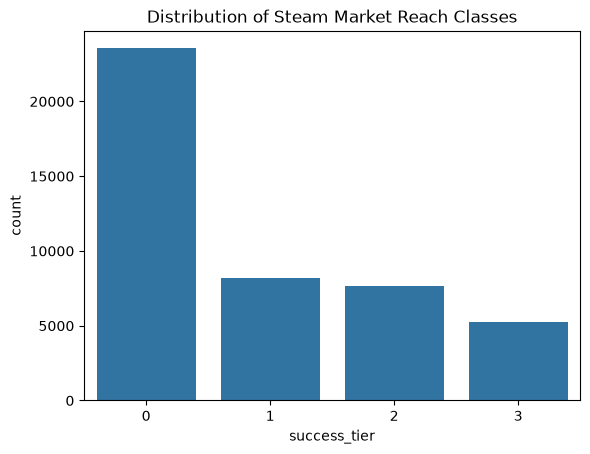

In [18]:
# success tier distribution
sns.countplot(
  data=df,
  x="success_tier"
)

plt.title(
  "Distribution of Steam Market Reach Classes"
)
plt.savefig("../reports/figures/success_distribution.png")

the distribution is imbalanced, so we cannot rely on accuracy, we'll probably use macro f1, confusion matrix

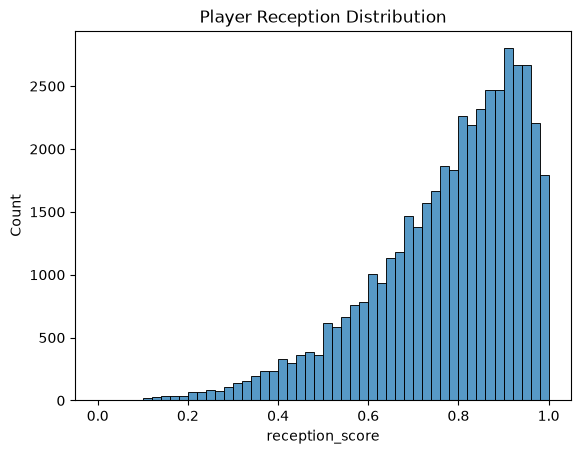

In [19]:
# Reception Distribution
sns.histplot(
    df["reception_score"],
    bins=50
)


plt.title(
    "Player Reception Distribution"
)


plt.savefig(
    "../reports/figures/reception_distribution.png"
)

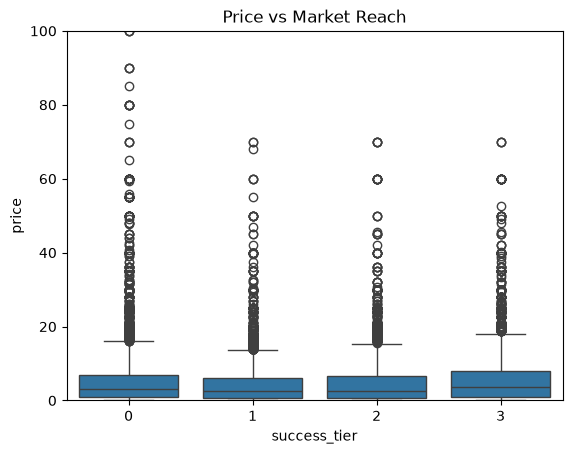

In [27]:
# Price Analysis

sns.boxplot(

    data=df,

    x="success_tier",

    y="price"

)


plt.ylim(
    0,
    100
)


plt.title(
    "Price vs Market Reach"
)

plt.savefig(
    "../reports/figures/Price_MarketReach.png"
)

In [21]:
# Free vs Paid games

df["is_free"] = df["price"] == 0

df.groupby("is_free")["owners_midpoint"].median()

is_free
False    10000.0
True     35000.0
Name: owners_midpoint, dtype: float64

<Axes: xlabel='platform_count', ylabel='owners_midpoint'>

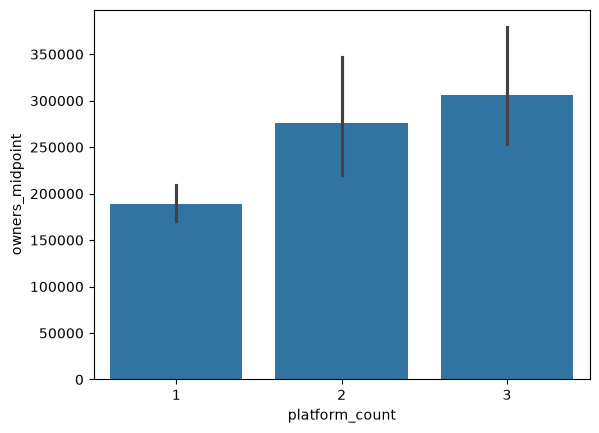

In [28]:
# Platform analysis
df["platform_count"] = (

df["windows"].astype(int)

+

df["mac"].astype(int)

+

df["linux"].astype(int)

)

sns.barplot(

data=df,

x="platform_count",

y="owners_midpoint"

)

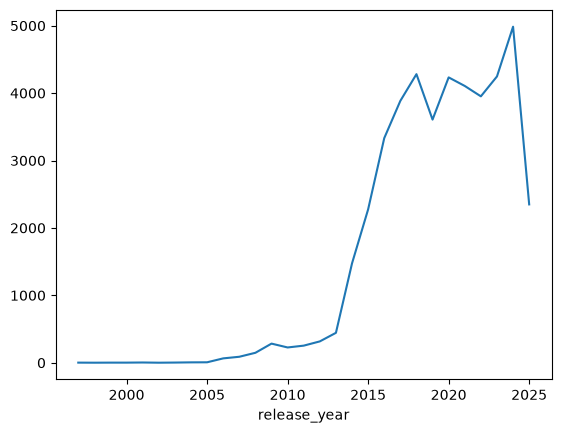

In [29]:
# Release Year Trends
df["release_date"] = pd.to_datetime(
    df["release_date"]
)
df["release_year"] = df["release_date"].dt.year

df["release_year"].value_counts().sort_index().plot()

plt.savefig(
    "../reports/figures/Release_year.png"
)